In [1]:
from pathlib import Path
import pandas as pd

pairs_path = Path('/scratch2/mlavechin/phorec/phonetically_transcribed_pairs/matched.txt')
pairs = pd.read_csv(pairs_path, sep='\t')


In [2]:
# Corpus-level analysis of quantity of data
from chat_toolkit.parser import parse_chat_file
from chat_toolkit.cha import Utterance
from tqdm.notebook import tqdm
import numpy as np
speaker_role2type = {
    'Target_Child': 'KCHI', 
    'Mother': 'ADU',
    'Investigator': 'ADU',
    'Father': 'ADU',
    'Target_Adult': 'ADU', 
    'Visitor': 'ADU',
    'Therapist': 'ADU',
    'Adult': 'ADU',
    'Brother': 'CHI',
    'Unidentified': 'OTH',
    'Grandmother': 'ADU',
    'Child': 'CHI',
    'Other': 'OTH',
    'Relative': 'ADU',
    'Media': 'OTH',
    'Participant': 'ADU',
    'Group': 'OTH',
    'Friend': 'ADU',
    'Sister': 'CHI',
    'Nurse': 'ADU',
    'Caretaker': 'ADU',
    'Grandfather': 'ADU',
    'Boy': 'CHI',
    'Sibling': 'CHI',
    'Student': 'CHI',
    'Speaker': 'ADU',
    'Teacher': 'ADU',
    'Playmate': 'CHI',
    'Girl': 'CHI',
    'Teenager': 'ADU',
    'Environment': 'ADU',
    'Male': 'ADU',
    'Uncertain': 'OTH',
}

out = []
for corpus in tqdm(np.sort(pairs['corpus'].unique())):
    print(f'Scanning {corpus}')
    sub_pairs = pairs[pairs.corpus == corpus]

    nb_utt = 0
    nb_transcribed_chi = 0
    nb_transcribed_adu = 0
    dur_transcribed_chi = 0
    dur_transcribed = 0
    for idx, row in sub_pairs.iterrows():
        transcript_path, audio_path = row['transcript'], row['audio']
        annotation = parse_chat_file(transcript_path)
        participants = annotation.participants
        file_nb_utt = len(annotation.utterances)
        file_design = annotation.design
        file_group = annotation.group
        file_activity = annotation.activity
        for utt in annotation.utterances:
            speaker_role = participants[utt.speaker]['role']
            speaker_type = speaker_role2type[speaker_role]
            utt_phones = (utt.dependent_tiers.get('pho') or 
                          utt.dependent_tiers.get('xpho') or 
                          utt.dependent_tiers.get('xARPABE') or 
                          None)
            out.append(
                {
                    'speaker_type': speaker_type,
                    'speaker_role': speaker_role,
                    'speaker': utt.speaker,
                    'content': utt.content,
                    'phones': utt_phones,
                    'onset':  utt.onset if isinstance(utt, Utterance) else float('nan'),
                    'offset': utt.offset if isinstance(utt, Utterance) else float('nan'),
                    'transcript_path': transcript_path,
                    'audio_path': audio_path,
                    'age': participants[utt.speaker]['age'],
                    'language': participants[utt.speaker]['language'],
                    'gender': participants[utt.speaker]['gender'],
                    'ses': participants[utt.speaker]['ses'],
                    'speaker_group': participants[utt.speaker]['group'],
                    'file_design': file_design,
                    'file_group': file_group,
                    'file_activity': file_activity,
                    'corpus': corpus
                }
            )
            
data = pd.DataFrame(out)
data['database'] = data['transcript_path'].str.split('/').str[7]
data['duration'] = data['offset']-data['onset']

  0%|          | 0/102 [00:00<?, ?it/s]

Scanning Aguirre
Scanning Almeida
Scanning Avram
Scanning BatEl
Scanning BermanLong
Scanning Bernstein
Scanning Bloom
Scanning Bracci
Scanning CCF
Scanning CCLAS
Scanning CLPF
Scanning CUHK
Scanning Cattini
Scanning Chiat
Scanning ChildL2
Scanning Chinese-Chang1
Scanning Chinese-Chang2
Scanning Cummings
Scanning Davis
Scanning DeHouwer
Scanning Deuchar
Scanning Edinburgh
Scanning FallsChurch
Scanning Florianopolis
Scanning FoxBoyer
Scanning GNP
Scanning Garmann
Scanning Geneva
Scanning Gildersleeve
Scanning Goad
Scanning GoadRose
Scanning Goga
Scanning Granada
Scanning Grimm
Scanning Groningen
Scanning Hunkeler
Scanning Istanbul
Scanning Jakarta
Scanning KernArabic
Scanning KernFrench
Scanning KernRomanian
Scanning Koine
Scanning Kuwaiti
Scanning Lahrouchi
Scanning LeNormand
Scanning LlinasOjea
Scanning Lyon
Scanning MCF
Scanning MOC
Scanning MacWhinney
Scanning Masdottir
Scanning Matlhaku
Scanning McAllister
Scanning Menn
Scanning NSCtoys
Scanning NeumannFoxBoyer
Scanning NewEngland
S

In [3]:
# Keep only PhonBank data
original_len = len(data)
data = data[data['database'] == 'phon']

# Keep only authorized_languages
def only_contains_authorized_langs(lang_str):
    authorized_langs = ['fra', 'spa', 'por', 'eng', 'deu']
    if pd.isna(lang_str):
        return False
    languages = [lang.strip() for lang in lang_str.split(',')]

    return all(lang in authorized_langs for lang in languages)

data = data[data['language'].apply(only_contains_authorized_langs)].reset_index(drop=True)

print(f'Original length: {original_len}')
print(f'New length: {len(data)}')

Original length: 4197575
New length: 1814536


In [4]:
# We keep only timestamped KCHI utterances
data = data[data['speaker_type'] == 'KCHI']
data = data[(~data.onset.isna()) & (~data.offset.isna())]
data = data[~data['phones'].isna()]

print("Total number of utterances per corpus")
for corpus, group in data.groupby('corpus'):
    transcribed_group = group[~group['phones'].isna()]

    # Parse languages
    all_languages = []
    for languages in transcribed_group['language']:
        langs = [lang.strip() for lang in languages.split(',')]
        all_languages.extend(langs)
    unique_languages = sorted(set(all_languages))

    # Compute cumulated duration
    cum_dur = (group['offset']-group['onset']).sum()/(1000*60*60)
    print(corpus, len(group), len(transcribed_group), cum_dur, end=' ')
    print(",".join(unique_languages))

import re

def age_to_months(age_str):
    # Handle missing or invalid values
    if pd.isna(age_str) or not isinstance(age_str, str):
        return None
    
    # Parse the age string using regex
    # Format: 'Y;MM.DD' (years;months.days)
    match = re.match(r'(\d+);(\d+)\.(\d+)', age_str)
    
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        days = int(match.group(3))
        
        # Convert to total months (approximating days as fraction of month)
        # Assuming 30 days per month for simplicity
        total_months = years * 12 + months + days / 30.0
        
        # Round to 2 decimal places for readability
        return round(total_months, 2)
    else:
        return None

# Apply the function to create the new column
data['age_months'] = data['age'].apply(age_to_months)
tot_cum_dur = (data['offset']-data['onset']).sum()/(1000*60*60)
print(f"Found {tot_cum_dur} hours in total.")

Total number of utterances per corpus
CCF 32051 32051 27.819608055555555 por
Cattini 745 745 0.28459972222222224 fra
Chiat 1245 1245 0.5252916666666667 eng
ChildL2 50694 50694 33.63321583333333 eng
Cummings 22105 22105 13.169875 eng
Davis 80004 80004 64.1796311111111 eng
FoxBoyer 3012 3012 0.7568663888888889 deu,eng
Goad 8843 8843 3.665045833333333 eng
GoadRose 7058 7058 3.149687777777778 fra
Granada 2069 2069 1.3636161111111111 spa
Grimm 8436 8436 14.229028611111112 deu
Hunkeler 2408 2408 8.982520277777779 fra
KernFrench 48732 48732 31.656900555555556 fra
Lyon 57444 57444 54.977420555555554 eng,fra
McAllister 4247 4247 2.0732155555555556 eng
Menn 796 796 0.27385166666666666 eng
NeumannFoxBoyer 2650 2650 0.72633 deu,por
PAIDUS-German 16079 16079 17.710284722222223 deu
PAIDUS-Spanish 8046 8046 7.433418888888889 spa
PERCEPT-GFTA 19447 19447 4.193515555555556 eng
PERCEPT-R 104437 104437 31.568728888888888 eng
Paris 62963 62963 53.230673055555556 fra,por
Penney 1411 1411 0.9205363888888889

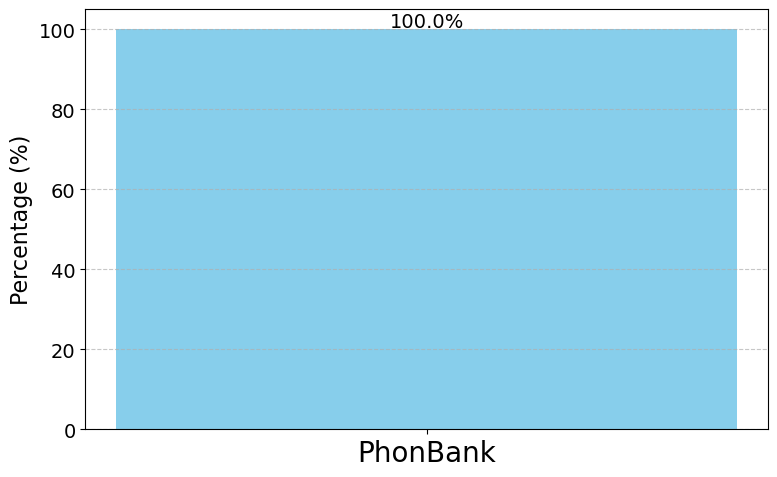

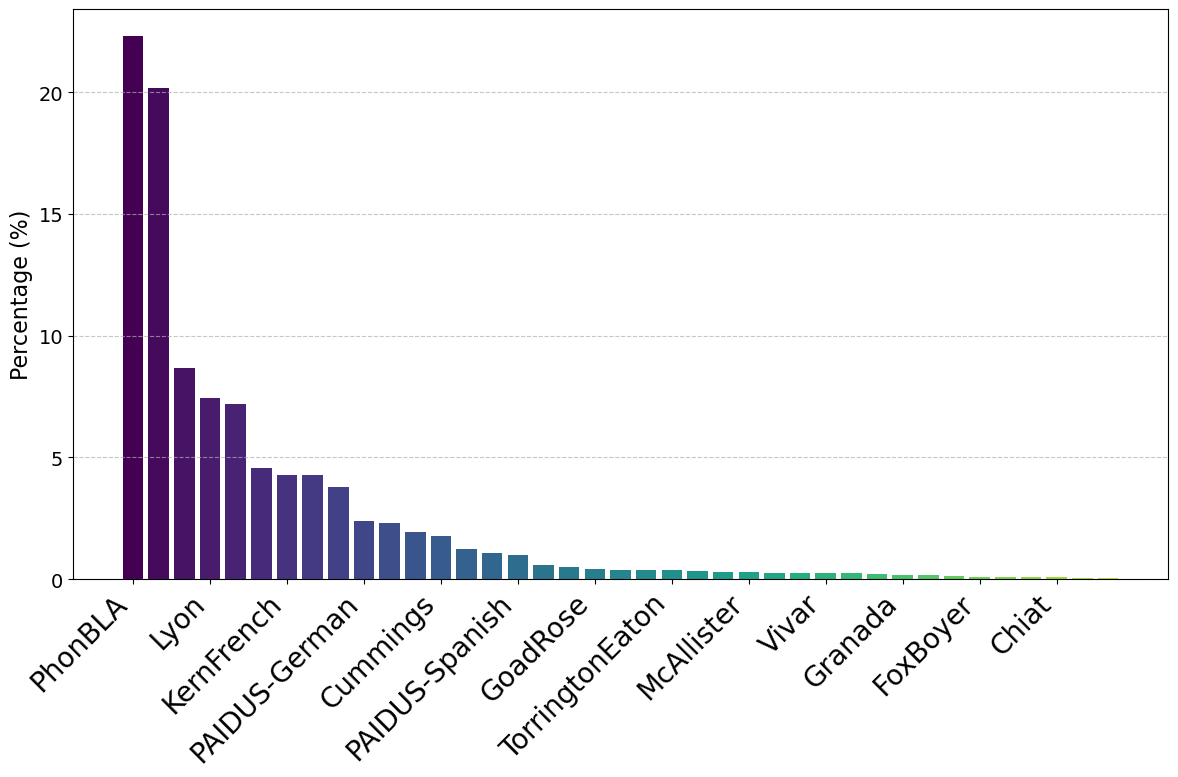

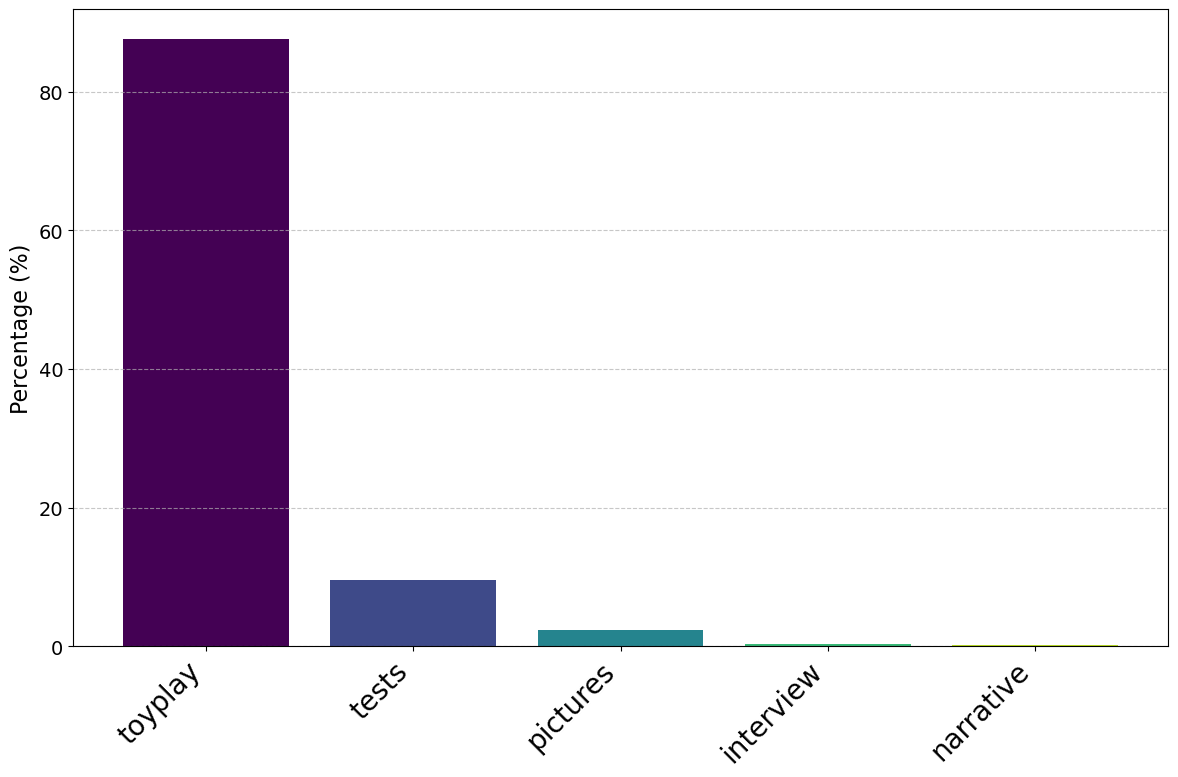

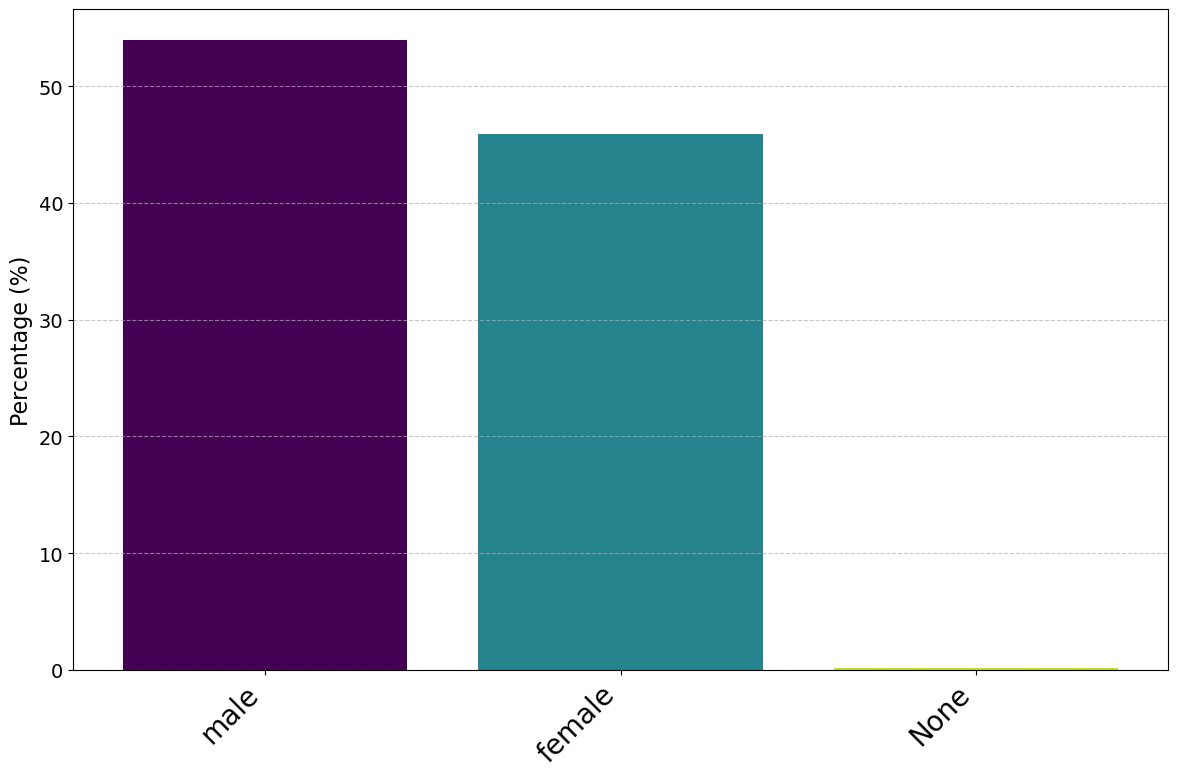

In [5]:

# 1) DATABASE CONTRIBUTION
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams.update({
    'font.size': 14,
    'xtick.labelsize': 20,
    'axes.labelsize': 16
})

db_labels = {
    'phon': 'PhonBank',
    'childes': 'CHILDES',
    'homebank': 'HomeBank'
}


db_order = ['phon', 'childes', 'homebank']
db_labels = ['PhonBank', 'CHILDES', 'HomeBank']

db_totals = data.groupby('database')['duration'].sum()
total_duration = db_totals.sum()
percentages = (db_totals / total_duration) * 100
percentages = percentages.reindex(db_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(db_labels, percentages, color=['skyblue', 'lightgreen', 'salmon'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.5, f'{height:.1f}%', 
             ha='center', va='bottom')

plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('database_contribution_bar.png', dpi=300)
plt.show()

# 2) CORPUS CONTRIBUTION
corpus_totals = data.groupby('corpus')['duration'].sum()
percentages = (corpus_totals / total_duration) * 100
percentages = percentages.sort_values(ascending=False)

plt.figure(figsize=(12, 8))  # Adjust figure size based on number of corpora

colors = plt.cm.viridis(np.linspace(0, 0.9, len(percentages)))
bars = plt.bar(percentages.index, percentages.values, color=colors)

corpus_names = percentages.index.tolist()
x_positions = range(len(corpus_names))
displayed_ticks = x_positions[::3]  # Every 3rd position
displayed_labels = [corpus_names[i] for i in displayed_ticks]

plt.xticks(displayed_ticks, displayed_labels, rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('corpus_contributions.png', dpi=300)
plt.show()

# 3) ACTIVITIES CONTRIBUTION
activity_totals = data.groupby('file_activity')['duration'].sum()
percentages = (activity_totals / total_duration) * 100
percentages = percentages.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(percentages)))
positions = range(len(percentages))
bars = plt.bar(positions, percentages.values, color=colors)
x_labels = [str(x) if pd.notnull(x) else 'None/NaN' for x in percentages.index]
plt.xticks(positions, x_labels, rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('activity_contributions.png', dpi=300)
plt.show()

# 4) GENDER CONTRIBUTION
gender_totals = data.groupby('gender')['duration'].sum()
total_duration = gender_totals.sum()
percentages = (gender_totals / total_duration) * 100
percentages = percentages.sort_values(ascending=False)


plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(percentages)))
x_labels = [str(x) if x != '' else 'None' for x in percentages.index]
positions = range(len(percentages))
bars = plt.bar(positions, percentages.values, color=colors)
plt.xticks(positions, x_labels, rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('gender_contributions.png', dpi=300)
plt.show()

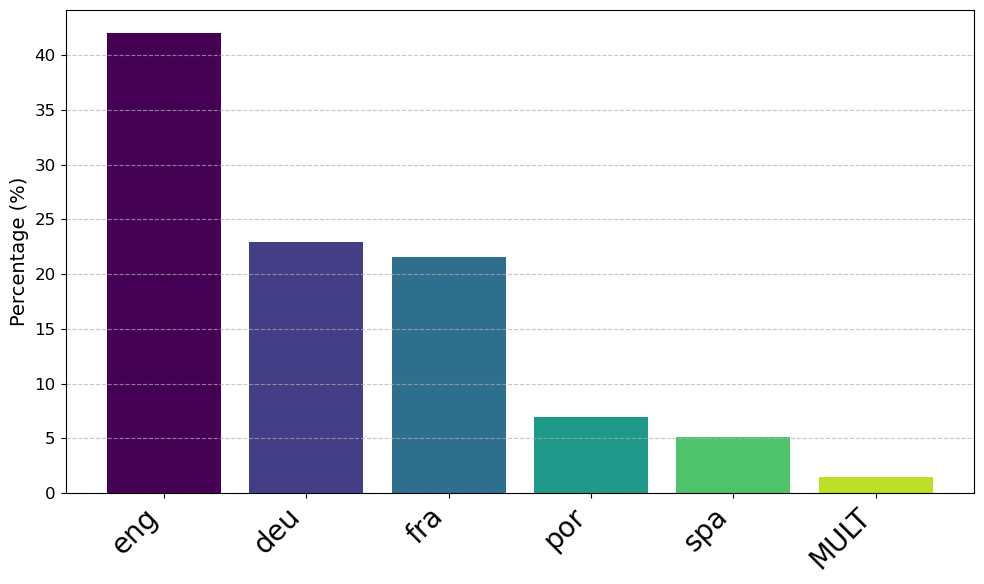

In [6]:
# LANGUAGE CONTRIBUTION
data_lang = data.copy()

def map_language(lang):
    if ',' in str(lang) or ';' in str(lang) or ' ' in str(lang):
        return 'MULT'
    else:
        return lang

data_lang['language_mapped'] = data_lang['language'].apply(map_language)

language_totals = data_lang.groupby('language_mapped')['duration'].sum()

total_duration = language_totals.sum()
percentages = (language_totals / total_duration) * 100
percentages = percentages.sort_values(ascending=False)

plt.rcParams.update({
    'font.size': 12,
    'xtick.labelsize': 20,
})

plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(percentages)))

bars = plt.bar(range(len(percentages)), percentages.values, color=colors)
plt.ylabel('Percentage (%)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

language_codes = percentages.index.tolist()
x_positions = range(len(language_codes))
plt.xticks(x_positions, language_codes, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('language_contributions.png', dpi=300)
plt.show()

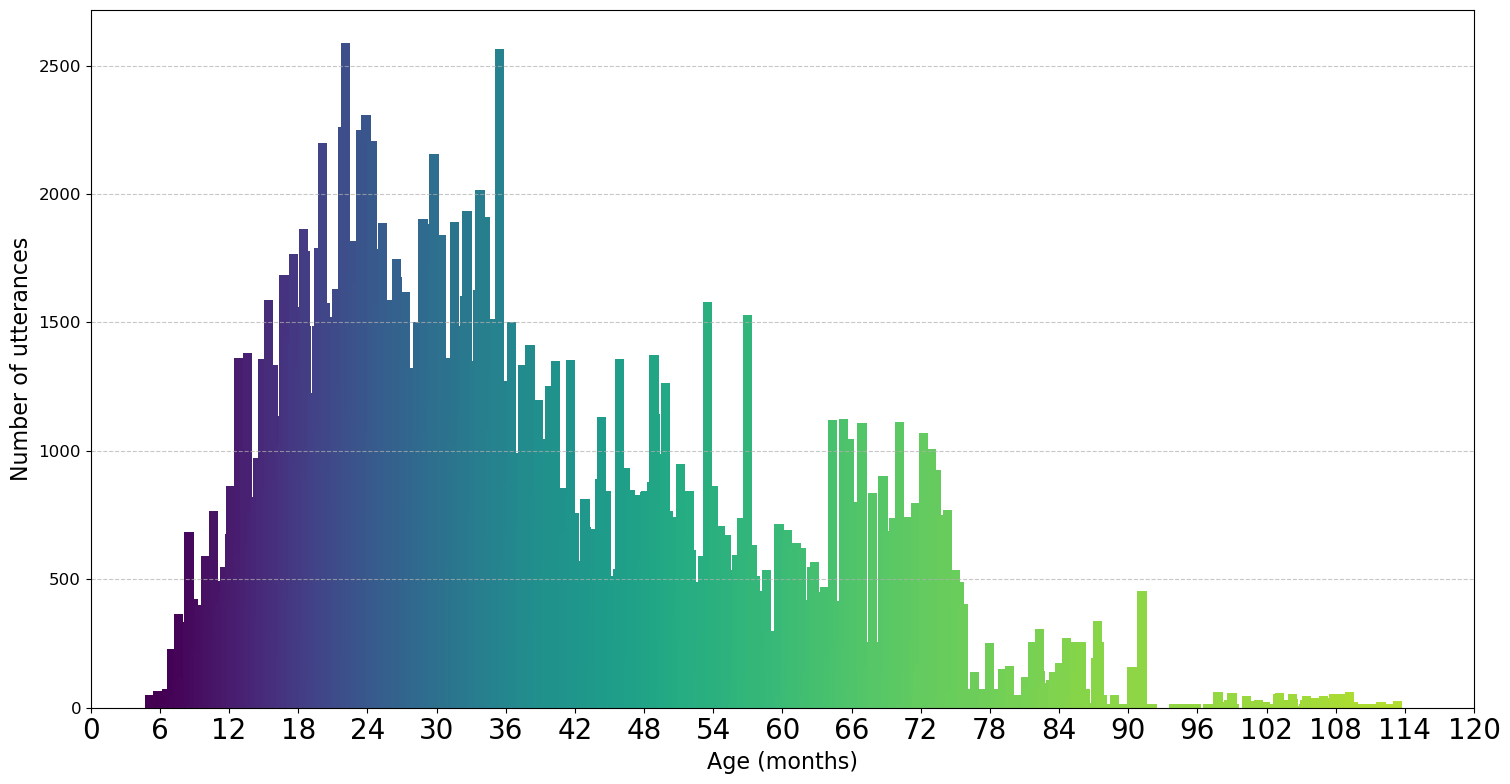

In [7]:
# AGE DISTRIBUTION
age_counts = data.groupby('age_months').size()
plt.figure(figsize=(15, 8))
age_counts = age_counts.sort_index()

bars = plt.bar(age_counts.index, age_counts.values, width=0.8, 
               color=plt.cm.viridis(np.linspace(0, 0.9, len(age_counts))))
plt.xlabel('Age (months)')
plt.ylabel('Number of utterances')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# If there are many age points, consider showing ticks every 6 months
if len(age_counts) > 20:
    # Get the min and max ages
    min_age = min(age_counts.index)
    max_age = max(age_counts.index)
    
    # Create tick positions every 6 months
    tick_positions = np.arange(
        np.floor(min_age / 6) * 6,  # Round down to nearest 6 months
        np.ceil(max_age / 6) * 6 + 1,  # Round up to nearest 6 months
        6
    )
    
    plt.xticks(tick_positions)

plt.tight_layout()
plt.xlim(0, 120)
plt.savefig('utterances_by_age.png', dpi=300)
plt.show()

In [11]:
# Super important replacement (otherwise the string won't be parsed by panphon)
data['phones'] = data['phones'].str.replace('g', 'ɡ')
data['phones'] = data['phones'].str.replace('ɝ', 'ər')
data['phones'] = data['phones'].str.replace('ɚ', 'ər')
data['phones'] = data['phones'].str.replace('͡', '')
data.to_csv('/scratch2/mlavechin/phorec/phonetically_transcribed_pairs/utterances.csv', sep='\t', index=False)

,speaker_type,speaker_role,speaker,content,phones,onset,offset,transcript_path,audio_path,age,...,gender,ses,speaker_group,file_design,file_group,file_activity,corpus,database,duration,age_months
